# AdaLoRA 交互教学

配套 lecture：[`../lectures/02-adalora.md`](../lectures/02-adalora.md)  
配套论文：[`../papers/02-adalora-2023.pdf`](../papers/02-adalora-2023.pdf)

本 notebook 演示：
1. 环境检查
2. 手写 minimal AdaLoRA（SVD 形式 P Λ Q^T）
3. peft AdaLoraConfig 调包
4. 立方衰减剪枝调度（公式 4）
5. **mini training**：含正交正则 + 重要性打分 + 周期性剪枝
6. **重要性 heatmap 可视化**：每层每个 λ 的 S_ema 演化
7. 思考题

In [1]:
import sys
from pathlib import Path
import torch, transformers, peft
print(f'torch: {torch.__version__}, peft: {peft.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.13.0.dev20260602+cu130, peft: 0.19.1
CUDA: True


## 2. 手写 minimal AdaLoRA

In [2]:
src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from adalora_minimal import AdaLoRAGPT2, AdaLoRALinear, cubic_schedule
from common import print_param_summary

torch.manual_seed(42)
model = AdaLoRAGPT2(r_init=12, alpha=16, ortho_lambda=0.1)
print_param_summary(model, 'AdaLoRA (r_init=12)')

layer0 = model.lm.transformer.h[0].attn.c_attn
print(f'\n第一层 layer 0:')
print(f'  P shape: {tuple(layer0.P.shape)}')
print(f'  Λ shape: {tuple(layer0.Lambda.shape)}  (初始全零)')
print(f'  Q shape: {tuple(layer0.Q.shape)}')
print(f'  S_ema:   {layer0.S_ema.tolist()}')
print(f'  mask:    {layer0.mask.tolist()}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16347.33it/s]

  AdaLoRA (r_init=12)
  Total params:      124,882,320
  Trainable params:      442,512  (0.3543%)
  Frozen params:     124,439,808

第一层 layer 0:
  P shape: (2304, 12)
  Λ shape: (12,)  (初始全零)
  Q shape: (768, 12)
  S_ema:   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  mask:    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 3. peft AdaLoraConfig 调包

In [3]:
from adalora_peft import build_peft_model

torch.manual_seed(42)
peft_model = build_peft_model(r_init=12, r_final=8, alpha=16)
print_param_summary(peft_model, 'peft AdaLoRA')

print('\npeft 命名: lora_A=Q^T, lora_E=Λ, lora_B=P')
for name, p in peft_model.named_parameters():
    if 'h.0.attn.c_attn' in name and ('lora_' in name):
        print(f'  {name}: shape={tuple(p.shape)}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15474.82it/s]

W0603 15:43:04.356000 46908 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


  peft AdaLoRA
  Total params:      124,882,332
  Trainable params:      442,512  (0.3543%)
  Frozen params:     124,439,820

peft 命名: lora_A=Q^T, lora_E=Λ, lora_B=P
  base_model.model.transformer.h.0.attn.c_attn.lora_A.default: shape=(12, 768)
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default: shape=(2304, 12)
  base_model.model.transformer.h.0.attn.c_attn.lora_E.default: shape=(12, 1)


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\adalora\model.py:203: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 4. 立方衰减剪枝调度（公式 4）

C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 20943 (\N{CJK UNIFIED IDEOGRAPH-51CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46908\974076089.py:18: UserWarning: Glyph 26525 (\N{CJK 

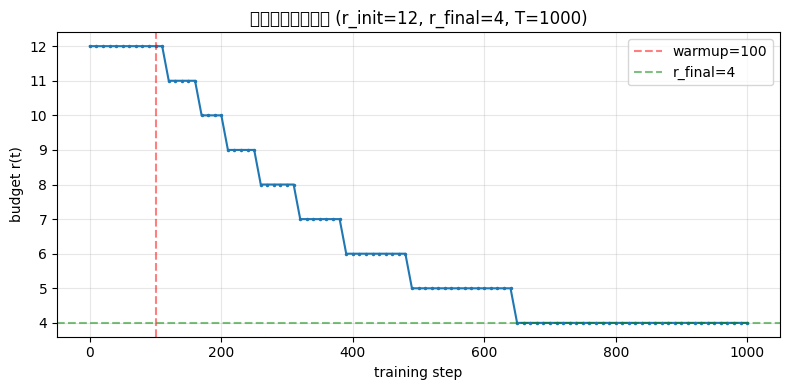

→ 前 t_warmup 维持 r_init，之后立方衰减到 r_final


In [4]:
import matplotlib.pyplot as plt

t_warmup, T = 100, 1000
r_init, r_final = 12, 4

steps = list(range(0, T + 1, 10))
rs = [cubic_schedule(t, t_warmup, T, r_init, r_final) for t in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, rs, marker='.', markersize=3)
plt.axvline(t_warmup, color='red', linestyle='--', alpha=0.5, label=f'warmup={t_warmup}')
plt.axhline(r_final, color='green', linestyle='--', alpha=0.5, label=f'r_final={r_final}')
plt.xlabel('training step')
plt.ylabel('budget r(t)')
plt.title(f'立方衰减剪枝调度 (r_init={r_init}, r_final={r_final}, T={T})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('→ 前 t_warmup 维持 r_init，之后立方衰减到 r_final')

## 5. Mini training：含正交正则 + 重要性 + 剪枝

In [5]:
torch.manual_seed(42)
model = AdaLoRAGPT2(r_init=12, alpha=16, ortho_lambda=0.1)
tok = model.tokenizer
inputs = tok([
    'hello world this is a test sentence',
    'i love this amazing wonderful product',
    'absolutely terrible movie do not buy',
    'fantastic experience from start to finish',
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=5e-3
)

T_total = 60
t_warmup = 10
r_final = 4
loss_history = []
ortho_history = []
rank_history = []
importance_snapshots = {}

for step in range(T_total):
    optimizer.zero_grad()
    out = model(**inputs)
    ortho = model.total_ortho_loss()
    (out.loss + ortho).backward()
    model.update_all_importance(beta=0.85)
    optimizer.step()
    loss_history.append(out.loss.item())
    ortho_history.append(ortho.item())
    
    # 剪枝（每 5 step 一次）
    if step >= t_warmup and step % 5 == 0:
        r_t = cubic_schedule(step, t_warmup, T_total, 12, r_final)
        model.prune_all_to(r_t)
    
    rank_history.append(model.get_active_ranks()[0])  # 取第一层
    
    if step in [0, 10, 20, 30, 50]:
        importance_snapshots[step] = model.get_all_importance().clone()

print(f'最终 loss: {loss_history[-1]:.4f}')
print(f'最终所有层激活秩: {model.get_active_ranks()}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14355.75it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


最终 loss: 0.0344
最终所有层激活秩: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


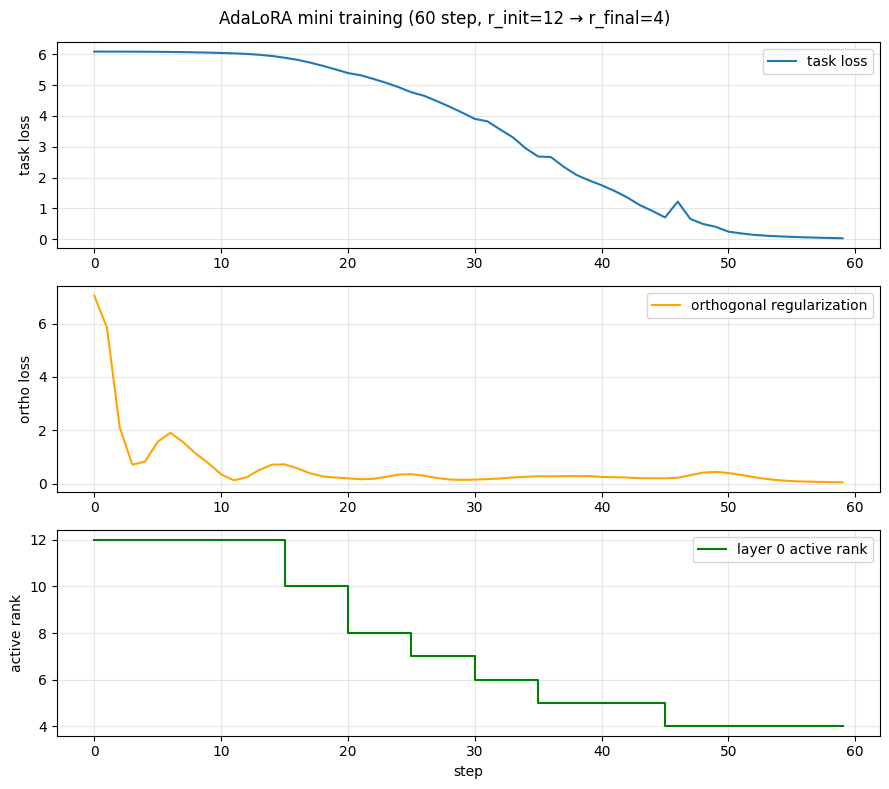

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8))
axes[0].plot(loss_history, label='task loss')
axes[0].set_ylabel('task loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(ortho_history, color='orange', label='orthogonal regularization')
axes[1].set_ylabel('ortho loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(rank_history, drawstyle='steps-post', color='green', label='layer 0 active rank')
axes[2].set_xlabel('step')
axes[2].set_ylabel('active rank')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle('AdaLoRA mini training (60 step, r_init=12 → r_final=4)')
plt.tight_layout()
plt.show()

## 6. 重要性 heatmap 可视化

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25171 (\N{CJK UNIFIED IDEOGRAPH-6253}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python

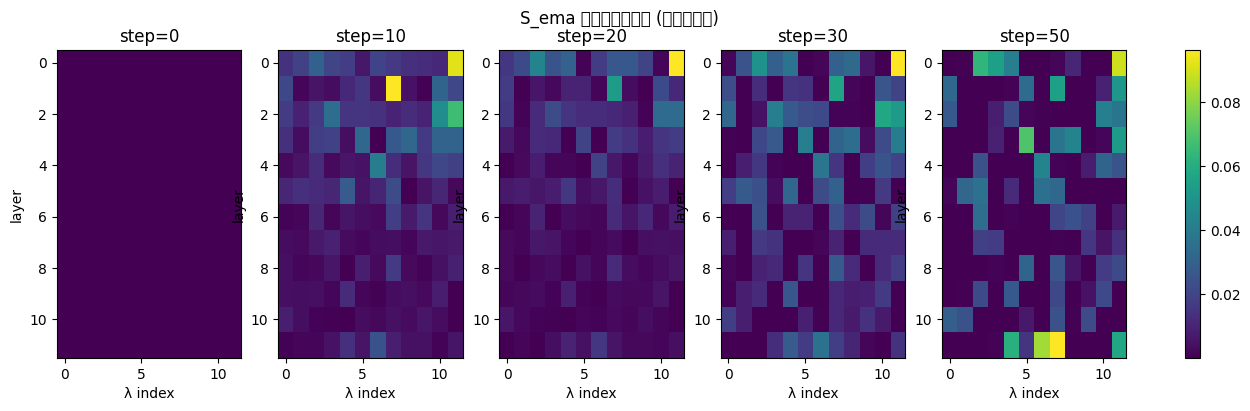

→ 越深的层（下方）通常打分越高，与论文 Figure 3 一致


In [7]:
fig, axes = plt.subplots(1, len(importance_snapshots), figsize=(15, 4))
for ax, (step, S) in zip(axes, importance_snapshots.items()):
    im = ax.imshow(S.cpu().numpy(), aspect='auto', cmap='viridis')
    ax.set_title(f'step={step}')
    ax.set_xlabel('λ index')
    ax.set_ylabel('layer')
plt.colorbar(im, ax=axes, fraction=0.03)
plt.suptitle('S_ema 重要性打分演化 (越亮越重要)')
plt.show()
print('→ 越深的层（下方）通常打分越高，与论文 Figure 3 一致')

## 7. 思考题

1. **公式题**：证明 ΔW = BA 与 ΔW = P Λ Q^T 在 r 相同下表达力等价。给出 (B, A) ↔ (P, Λ, Q) 的具体变换。
2. **公式题**：推导 ∂L/∂λ_i。它与 LoRA 的 ∂L/∂B 有什么关系？
3. **代码题**：把 `prune_to` 改成'软剪枝'（mask 乘 0.1 而非 0），观察对 loss 的影响。
4. **设计题**：把 `ortho_lambda=0` 跑 mini training，看 P^T P 偏离 I 多远（用 norm 量化）。
5. **对比题**：AdaLoRA 与'先训大 r 再 SVD 截断'在数学上有什么本质差异？
6. **实践题**：把 `delta_T` 从 5 改成 1 或 20，比较剪枝频率对收敛的影响。